In [2]:
%pip install qiskit[visualization] qiskit-ibm-runtime qiskit-aer qiskit_qasm3_import

  Using cached qiskit_ibm_runtime-0.43.1-py3-none-any.whl.metadata (21 kB)
  Using cached qiskit_aer-0.17.2-cp313-cp313-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (8.3 kB)
  Using cached qiskit_qasm3_import-0.6.0-py3-none-any.whl.metadata (7.2 kB)
  Using cached qiskit-2.2.3-cp39-abi3-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (12 kB)
  Using cached rustworkx-0.17.1-cp39-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (10 kB)
  Using cached numpy-2.3.4-cp313-cp313-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (62 kB)
  Using cached scipy-1.16.3-cp313-cp313-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (62 kB)
  Using cached dill-0.4.0-py3-none-any.whl.metadata (10 kB)
  Using cached stevedore-5.5.0-py3-none-any.whl.metadata (2.2 kB)
  Using cached typing_extensions-4.15.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached matplotlib-3.10.7-cp313-cp313-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (11 kB)
  Using cache

# Protocolo BB84 de Distribución Cuántica de Claves (QKD)

## Introducción

La **Distribución Cuántica de Claves (QKD)** representa una solución revolucionaria frente a las amenazas que la computación cuántica plantea a la criptografía clásica (RSA, ECC). A diferencia de los esquemas basados en factorización, QKD utiliza las propiedades fundamentales de la mecánica cuántica para garantizar la seguridad de la comunicación.

### El Protocolo BB84

En 1984, Charles Bennett y Gilles Brassard propusieron el protocolo **BB84**, el primer esquema de QKD. Los principios fundamentales son:

1. **Codificación cuántica**: Alice prepara qubits en dos bases diferentes (Z y X)
2. **Medición aleatoria**: Bob mide con bases aleatorias
3. **Reconciliación de bases**: Alice y Bob comparan bases públicamente
4. **Detección de espías**: Cualquier interceptación introduce errores detectables

### Formalismo Matemático

#### Estados Cuánticos

En la **base Z** (computacional):
$$|0\rangle = \begin{pmatrix} 1 \\ 0 \end{pmatrix}, \quad |1\rangle = \begin{pmatrix} 0 \\ 1 \end{pmatrix}$$

En la **base X** (Hadamard):
$$|+\rangle = \frac{1}{\sqrt{2}}(|0\rangle + |1\rangle), \quad |-\rangle = \frac{1}{\sqrt{2}}(|0\rangle - |1\rangle)$$

#### Tasa de Error Cuántica (QBER)

La seguridad del protocolo se basa en el **QBER** (Quantum Bit Error Rate), que mide la fracción de bits en los que difieren las claves “sifted” de Alice y Bob.  
Se define como:

$$\text{QBER} = \frac{\text{bits erróneos}}{\text{bits totales comparados}}$$

Este valor refleja tanto errores por ruido como posible información obtenida por un atacante (Eve).

En el protocolo **BB84**, se ha demostrado que si el error supera aproximadamente el **11 %**, **no puede extraerse una clave secreta segura**, incluso tras la corrección de errores y la amplificación de privacidad.

Matemáticamente, el límite proviene de comparaciones de información mutua entre las partes:

$$
I(A;B) > I(A;E)
$$

donde \(I(A;B)\) es la información compartida entre Alice y Bob, e \(I(A;E)\) la que obtiene Eve.  
Si el QBER supera el umbral (~11 %), se cumple que:

$$
I(A;B) \le I(A;E)
$$

y ya no es posible que Bob tenga más información sobre la clave que el espía.

##### Origen teórico del 11 %

Este límite se obtiene a partir del **teorema de Shor–Preskill (2000)**, que demuestra la seguridad del BB84 modelando el protocolo como un esquema de **purificación de entrelazamiento** seguido de un **código de corrección de errores CSS**.  
El análisis muestra que cuando el QBER aumenta, los códigos ya no pueden corregir suficientes errores sin filtrar demasiada información.

Por encima de esos valores, Eve puede obtener **más información que Bob**, lo que hace imposible extraer bits verdaderamente secretos.


##### Interpretación física

- Si el **QBER < 11 %**, los errores se atribuyen principalmente al ruido o imperfecciones del canal, y la clave puede purificarse con procedimientos de reconciliación.  
- Si el **QBER > 11 %**, los errores implican que Eve tiene una correlación comparable o mayor que Bob, invalidando la seguridad de la clave.

---

#### Probabilidad de Detección

Con $m$ bits de prueba, la probabilidad de detectar a Eve es:

$$P_d = 1 - (0.75)^m$$

Para $m = 50$, $P_d \approx 99.9999\%$


## Implementación

En este notebook implementaremos:

1. **Protocolo BB84 básico**: Codificación, transmisión y medición de qubits
2. **Detección de espías**: Estimación del QBER y verificación de seguridad
3. **Modelos de ruido**: Simulación de canales cuánticos realistas
4. **Post-procesamiento**: Reconciliación de errores (Cascade) y amplificación de privacidad
5. **Aplicación práctica**: Cifrado simétrico con la clave generada
6. **Análisis de rendimiento**: Métricas y visualizaciones

---

## 1. Instalación de Dependencias


---

## 2. Imports y Configuración Global

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys
import io
import hashlib
import os
import base64
import time

from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit_aer.noise import (
    NoiseModel, depolarizing_error, phase_damping_error,
    amplitude_damping_error, ReadoutError
)
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime import SamplerV2 as Sampler
from qiskit.visualization import plot_histogram

from cryptography.fernet import Fernet
from cryptography.hazmat.primitives import hashes
from cryptography.hazmat.primitives.kdf.pbkdf2 import PBKDF2HMAC
from cryptography.hazmat.backends import default_backend

# Parámetros globales del protocolo BB84
N_QUBITS = 200        # Número de qubits a transmitir
TEST_SIZE = 50        # Bits para verificación de seguridad
QBER_THRESHOLD = 0.11 # Umbral de error máximo (11%)
BLOCK_SIZE = 4        # Tamaño de bloque para reconciliación

# Semilla para reproducibilidad
np.random.seed(42)

print("✓ Configuración inicializada")
print(f"  N_QUBITS: {N_QUBITS}")
print(f"  TEST_SIZE: {TEST_SIZE}")
print(f"  QBER_THRESHOLD: {QBER_THRESHOLD*100}%")


✓ Configuración inicializada
  N_QUBITS: 200
  TEST_SIZE: 50
  QBER_THRESHOLD: 11.0%


---

## 3. Funciones Auxiliares del Protocolo BB84

### 3.1 Codificación de Qubits

In [2]:
def encode_qubit(bit, base):
    """
    Codifica un bit clásico en un qubit según la base especificada.
    
    Args:
        bit (int): Bit clásico (0 o 1)
        base (int): Base de codificación (0=Z, 1=X)
        
    Returns:
        QuantumCircuit: Circuito cuántico con el qubit codificado
    """
    qc = QuantumCircuit(1, 1)
    
    if bit == 1:
        qc.x(0)
    
    if base == 1:
        qc.h(0)
    
    return qc


def measure_qubit(qc, base):
    """
    Añade medición al circuito en la base especificada.
    
    Args:
        qc (QuantumCircuit): Circuito cuántico
        base (int): Base de medición (0=Z, 1=X)
        
    Returns:
        QuantumCircuit: Circuito con medición añadida
    """
    if base == 1:
        qc.h(0)
    
    qc.measure(0, 0)
    return qc


### 3.2 Funciones de Generación y Medición


In [3]:
def generar_datos_alice(n):
    """
    Genera bits y bases aleatorias para Alice.
    
    Args:
        n (int): Número de qubits a generar
        
    Returns:
        tuple: (bits_alice, bases_alice)
    """
    bits_alice = np.random.randint(2, size=n)
    bases_alice = np.random.randint(2, size=n)
    return bits_alice, bases_alice


def codificar_qubits(bits, bases):
    """
    Crea circuitos cuánticos para cada par bit-base.
    
    Args:
        bits (array): Array de bits clásicos
        bases (array): Array de bases de codificación
        
    Returns:
        list: Lista de QuantumCircuit
    """
    lista_circuitos = []
    for bit, base in zip(bits, bases):
        qc = QuantumCircuit(1, 1)
        
        if bit == 1:
            qc.x(0)
        
        if base == 1:
            qc.h(0)
        
        qc.id(0)  # Compuerta identidad para el canal cuántico
        lista_circuitos.append(qc)
    
    return lista_circuitos


def generar_bases_bob(n):
    """
    Genera bases de medición aleatorias para Bob.
    
    Args:
        n (int): Número de bases a generar
        
    Returns:
        array: Bases de medición aleatorias
    """
    return np.random.randint(2, size=n)


def medir_qubits_bob(lista_circuitos, bases_bob, pm, sampler_inst):
    """
    Simula la medición de Bob sobre los qubits recibidos.
    
    Args:
        lista_circuitos (list): Lista de circuitos cuánticos
        bases_bob (array): Bases de medición de Bob
        pm (PassManager): Pass manager para transpilación
        sampler_inst (Sampler): Sampler para ejecución
        
    Returns:
        array: Bits medidos por Bob
    """
    bits_bob = []
    circuitos_medicion = []
    
    for i, qc in enumerate(lista_circuitos):
        base_bob = bases_bob[i]
        
        if base_bob == 1:
            qc.h(0)
        
        qc.measure(0, 0)
        circuitos_medicion.append(qc)
    
    circuitos_isa = pm.run(circuitos_medicion)
    job = sampler_inst.run(circuitos_isa, shots=1)
    result = job.result()
    
    for pub_result in result:
        counts = pub_result.data.c.get_counts()
        measured_bit_str = list(counts.keys())[0]
        bits_bob.append(int(measured_bit_str))
    
    return np.array(bits_bob)


### 3.3 Sifting y Verificación de Seguridad


In [4]:
def sift_keys(bases_alice, bases_bob, bits_alice, bits_bob):
    """
    Compara bases y filtra bits donde coincidieron.
    
    Args:
        bases_alice (array): Bases de Alice
        bases_bob (array): Bases de Bob
        bits_alice (array): Bits de Alice
        bits_bob (array): Bits medidos por Bob
        
    Returns:
        tuple: (sifted_alice, sifted_bob)
    """
    sifted_alice = []
    sifted_bob = []
    
    for i in range(len(bases_alice)):
        if bases_alice[i] == bases_bob[i]:
            sifted_alice.append(bits_alice[i])
            sifted_bob.append(bits_bob[i])
    
    return np.array(sifted_alice), np.array(sifted_bob)


def check_for_eve(sifted_key_alice, sifted_key_bob, test_size):
    """
    Calcula el QBER comparando una muestra de bits.
    
    Args:
        sifted_key_alice (array): Clave filtrada de Alice
        sifted_key_bob (array): Clave filtrada de Bob
        test_size (int): Número de bits a comparar
        
    Returns:
        tuple: (qber, final_key_alice)
    """
    if len(sifted_key_alice) < test_size:
        return None, None
    
    test_bits_alice = sifted_key_alice[:test_size]
    test_bits_bob = sifted_key_bob[:test_size]
    
    diferencias = np.sum(test_bits_alice != test_bits_bob)
    qber = diferencias / test_size
    
    final_key_alice = sifted_key_alice[test_size:]
    
    return qber, final_key_alice


---

## 4. Post-Procesamiento

### 4.1 Reconciliación de Errores (Protocolo Cascade)

El protocolo **Cascade** permite corregir errores mediante búsqueda binaria iterativa:

1. Divide la clave en bloques
2. Compara paridades públicamente
3. Localiza errores mediante búsqueda binaria
4. Aplica múltiples pasadas con barajado (shuffling)


In [5]:
def _cascade_binary_search(alice_key, bob_key_to_correct, start, end):
    """
    Búsqueda binaria recursiva para localizar errores en un bloque.
    
    Args:
        alice_key (array): Clave de Alice (referencia)
        bob_key_to_correct (array): Clave de Bob (se modifica in-place)
        start (int): Índice inicial del bloque
        end (int): Índice final del bloque
        
    Returns:
        int: Número de errores encontrados
    """
    if (end - start) == 1:
        bob_key_to_correct[start] = 1 - bob_key_to_correct[start]
        return 1
    
    mid_point = start + (end - start) // 2
    errors_found = 0
    
    parity_alice_left = np.sum(alice_key[start:mid_point]) % 2
    parity_bob_left = np.sum(bob_key_to_correct[start:mid_point]) % 2
    
    if parity_alice_left != parity_bob_left:
        errors_found += _cascade_binary_search(alice_key, bob_key_to_correct, start, mid_point)
    
    parity_alice_right = np.sum(alice_key[mid_point:end]) % 2
    parity_bob_right = np.sum(bob_key_to_correct[mid_point:end]) % 2
    
    if parity_alice_right != parity_bob_right:
        errors_found += _cascade_binary_search(alice_key, bob_key_to_correct, mid_point, end)
    
    return errors_found


def _cascade_pass(alice_key, bob_key_to_correct, block_size):
    """
    Ejecuta una pasada completa de Cascade.
    
    Args:
        alice_key (array): Clave de Alice
        bob_key_to_correct (array): Clave de Bob
        block_size (int): Tamaño de los bloques
        
    Returns:
        int: Número de errores encontrados
    """
    errors_found_pass = 0
    num_blocks = len(alice_key) // block_size
    
    if num_blocks == 0:
        return 0
    
    for i in range(num_blocks):
        start_index = i * block_size
        end_index = (i + 1) * block_size
        
        block_alice = alice_key[start_index:end_index]
        block_bob = bob_key_to_correct[start_index:end_index]
        
        parity_alice = np.sum(block_alice) % 2
        parity_bob = np.sum(block_bob) % 2
        
        if parity_alice != parity_bob:
            errors_found_pass += _cascade_binary_search(
                alice_key, bob_key_to_correct, start_index, end_index
            )
    
    return errors_found_pass


def reconcile_keys_cascade_full(alice_key, bob_key, num_passes=4):
    """
    Implementa el protocolo CASCADE completo con múltiples pasadas.
    
    Args:
        alice_key (array): Clave de Alice
        bob_key (array): Clave de Bob con errores
        num_passes (int): Número de pasadas (default: 4)
        
    Returns:
        tuple: (alice_key_corrected, bob_key_corrected)
    """
    print(f"\n🔧 Reconciliación Cascade ({num_passes} pasadas)...")
    
    bob_key_corrected = np.copy(bob_key)
    n = len(alice_key)
    
    block_sizes = [8 * (2**i) for i in range(num_passes)]
    permutations = []
    
    for i in range(num_passes):
        block_size = block_sizes[i]
        print(f"  Pasada {i+1}/{num_passes} (bloque={block_size})...", end=" ")
        
        if i > 0:
            perm = np.random.permutation(n)
            permutations.append(perm)
            alice_key = alice_key[perm]
            bob_key_corrected = bob_key_corrected[perm]
        
        errors = _cascade_pass(alice_key, bob_key_corrected, block_size)
        print(f"{errors} errores corregidos")
        
        if errors == 0 and i > 0:
            break
    
    for perm in reversed(permutations):
        inv_perm = np.argsort(perm)
        alice_key = alice_key[inv_perm]
        bob_key_corrected = bob_key_corrected[inv_perm]
    
    errors_remaining = np.sum(alice_key != bob_key_corrected)
    
    if errors_remaining == 0:
        print(f"  ✓ Reconciliación exitosa")
    else:
        print(f"  ⚠️  {errors_remaining} errores restantes")
    
    return alice_key, bob_key_corrected


def reconcile_keys(alice_key, bob_key, block_size=4):
    """
    Reconciliación simple basada en paridad (descarta bloques con error).
    
    Args:
        alice_key (array): Clave de Alice
        bob_key (array): Clave de Bob
        block_size (int): Tamaño de bloque
        
    Returns:
        array: Clave reconciliada
    """
    reconciled_key_alice = []
    num_blocks = len(alice_key) // block_size
    
    print(f"\n🔧 Reconciliación de Datos (Block size={block_size})...")
    
    for i in range(num_blocks):
        start = i * block_size
        end = (i + 1) * block_size
        
        block_alice = alice_key[start:end]
        block_bob = bob_key[start:end]
        
        parity_alice = np.sum(block_alice) % 2
        parity_bob = np.sum(block_bob) % 2
        
        if parity_alice == parity_bob:
            reconciled_key_alice.extend(block_alice)
    
    print(f"  ✓ Bloques conservados: {len(reconciled_key_alice)//block_size}/{num_blocks}")
    print(f"  ✓ Tamaño: {len(reconciled_key_alice)} bits")
    
    return np.array(reconciled_key_alice)


### 4.2 Amplificación de Privacidad

Después de la reconciliación, Eve puede tener información parcial sobre la clave. La **amplificación de privacidad** reduce exponencialmente esta información mediante compresión por XOR o hash criptográfico.


In [6]:
def amplify_privacy(reconciled_key):
    """
    Amplificación de privacidad mediante plegado con XOR.
    
    Args:
        reconciled_key (array): Clave reconciliada
        
    Returns:
        array: Clave final segura (tamaño reducido a la mitad)
    """
    n = len(reconciled_key)
    if n == 0:
        return np.array([])
    
    half_len = n // 2
    key_half_1 = reconciled_key[:half_len]
    key_half_2 = reconciled_key[half_len : 2 * half_len]
    
    print(f"\n🔐 Amplificación de Privacidad...")
    print(f"  ✓ Reduciendo clave de {n} → {half_len} bits")
    
    final_secure_key = np.bitwise_xor(key_half_1, key_half_2)
    
    return final_secure_key


---

## 5. Modelos de Ruido Cuántico

Los canales cuánticos reales sufren de varios tipos de ruido:

- **Depolarizing**: Mezcla total del estado cuántico
- **Phase Damping**: Pérdida de coherencia de fase
- **Amplitude Damping**: Pérdida de energía (decaimiento)
- **Readout Error**: Errores en el detector


In [7]:
def create_noise_model(p_amp=0.01, p_depol=0.015, p_readout=0.05):
    """
    Crea un modelo de ruido realista combinando múltiples canales.
    
    Args:
        p_amp (float): Probabilidad de amplitude damping
        p_depol (float): Probabilidad de depolarización
        p_readout (float): Probabilidad de error de lectura
        
    Returns:
        NoiseModel: Modelo de ruido configurado
    """
    err_amp = amplitude_damping_error(p_amp)
    err_depol = depolarizing_error(p_depol, 1)
    
    combined_error = err_depol.compose(err_amp)
    
    err_read = ReadoutError([[1 - p_readout, p_readout],
                            [p_readout, 1 - p_readout]])
    
    noise_model = NoiseModel()
    noise_model.add_all_qubit_quantum_error(combined_error,
                                           ['u1', 'u2', 'u3', 'id', 'x', 'h'])
    noise_model.add_all_qubit_readout_error(err_read)
    
    print(f"✓ Modelo de ruido configurado:")
    print(f"  - Amplitude damping: {p_amp*100}%")
    print(f"  - Depolarizing: {p_depol*100}%")
    print(f"  - Readout: {p_readout*100}%")
    
    return noise_model


def canal_clasico_con_ruido(bits, p_error_classic):
    """
    Simula errores en el canal clásico público.
    
    Args:
        bits (array): Bits a transmitir
        p_error_classic (float): Probabilidad de error
        
    Returns:
        array: Bits con errores introducidos
    """
    flips = np.random.rand(len(bits)) < p_error_classic
    return np.bitwise_xor(bits, flips.astype(int))


def sift_keys_con_ruido_clasico(bases_alice, bases_bob, bits_alice, bits_bob, p_error_classic):
    """
    Sifting con ruido en el canal clásico de comparación de bases.
    
    Args:
        bases_alice (array): Bases de Alice
        bases_bob (array): Bases de Bob
        bits_alice (array): Bits de Alice
        bits_bob (array): Bits de Bob
        p_error_classic (float): Probabilidad de error clásico
        
    Returns:
        tuple: (sifted_alice, sifted_bob)
    """
    bases_bob_recibidas = canal_clasico_con_ruido(bases_bob, p_error_classic)
    sifted_a, sifted_b = [], []
    
    for i in range(len(bases_alice)):
        if bases_alice[i] == bases_bob_recibidas[i]:
            sifted_a.append(bits_alice[i])
            sifted_b.append(bits_bob[i])
    
    return np.array(sifted_a), np.array(sifted_b)


---

## 6. Clase BB84Protocol

Implementación orientada a objetos del protocolo completo.


In [8]:
class BB84Protocol:
    """
    Implementación completa del protocolo BB84 con post-procesamiento.
    
    Attributes:
        n_qubits (int): Número de qubits a transmitir
        test_size (int): Bits para verificación de seguridad
        enable_eve (bool): Activar simulación de espía
        enable_postprocessing (bool): Activar reconciliación y amplificación
        block_size (int): Tamaño de bloque para reconciliación
        use_cascade (bool): Usar Cascade en lugar de reconciliación simple
    """
    
    def __init__(self, n_qubits=200, test_size=50,
                 noise_model=None, enable_eve=False,
                 enable_postprocessing=False, block_size=4, use_cascade=True):
        
        self.n_qubits = n_qubits
        self.test_size = test_size
        self.enable_eve = enable_eve
        self.enable_postprocessing = enable_postprocessing
        self.block_size = block_size
        self.use_cascade = use_cascade
        
        self.alice_bits = None
        self.alice_bases = None
        self.bob_bases = None
        self.bob_results = None
        self.eve_bases = None
        
        self.sifted_key_alice = None
        self.sifted_key_bob = None
        self.final_key_alice = None
        self.final_key_bob = None
        self.secure_key = None
        
        self.qber = None
        self.key_indices = None
        
        backend = AerSimulator(noise_model=noise_model) if noise_model else AerSimulator()
        self.backend = backend
        self.pm = generate_preset_pass_manager(backend=backend, optimization_level=1)
        self.sampler = Sampler(mode=backend)
    
    def alice_prepare(self):
        """Alice genera bits y bases aleatorias."""
        self.alice_bits = np.random.randint(2, size=self.n_qubits)
        self.alice_bases = np.random.randint(2, size=self.n_qubits)
        print(f"✓ Alice preparó {self.n_qubits} qubits")
    
    def bob_prepare(self):
        """Bob genera bases aleatorias."""
        self.bob_bases = np.random.randint(2, size=self.n_qubits)
        print(f"✓ Bob preparó {self.n_qubits} bases de medición")
    
    def eve_intercept(self, circuits):
        """Eve intercepta y reenvía qubits."""
        if not self.enable_eve:
            return circuits
        
        print(f"⚠️  Eve está interceptando {len(circuits)} qubits...")
        self.eve_bases = np.random.randint(2, size=self.n_qubits)
        
        eve_circuits = []
        for i, qc in enumerate(circuits):
            qc_copy = qc.copy()
            if self.eve_bases[i] == 1:
                qc_copy.h(0)
            qc_copy.measure(0, 0)
            eve_circuits.append(qc_copy)
        
        eve_isa = self.pm.run(eve_circuits)
        job = self.sampler.run(eve_isa, shots=1)
        result = job.result()
        
        eve_bits = [int(list(pub_result.data.c.get_counts().keys())[0])
                    for pub_result in result]
        
        new_circuits = [encode_qubit(bit, base)
                       for bit, base in zip(eve_bits, self.eve_bases)]
        
        return new_circuits
    
    def transmit_and_measure(self):
        """Transmisión cuántica completa."""
        print(f"\n🔄 Transmitiendo {self.n_qubits} qubits...")
        
        circuits = [encode_qubit(self.alice_bits[i], self.alice_bases[i])
                   for i in range(self.n_qubits)]
        
        circuits = self.eve_intercept(circuits)
        
        for i in range(self.n_qubits):
            circuits[i] = measure_qubit(circuits[i], self.bob_bases[i])
        
        circuits_isa = self.pm.run(circuits)
        job = self.sampler.run(circuits_isa, shots=1)
        result = job.result()
        
        self.bob_results = np.array([
            int(list(pub_result.data.c.get_counts().keys())[0])
            for pub_result in result
        ])
        
        print(f"✓ Bob midió todos los qubits")
    
    def sifting(self):
        """Reconciliación de bases."""
        print(f"\n🔍 Realizando sifting (reconciliación de bases)...")
        self.key_indices = np.where(self.alice_bases == self.bob_bases)[0]
        self.sifted_key_alice = self.alice_bits[self.key_indices]
        self.sifted_key_bob = self.bob_results[self.key_indices]
        
        coincidence_rate = len(self.key_indices) / self.n_qubits * 100
        print(f"✓ Bases coincidentes: {len(self.key_indices)}/{self.n_qubits} ({coincidence_rate:.1f}%)")
        print(f"  Tamaño de clave filtrada: {len(self.sifted_key_alice)} bits")
    
    def estimate_error_rate(self):
        """Calcula QBER."""
        print(f"\n📊 Estimando tasa de error (QBER)...")
        
        sample_size = min(self.test_size, len(self.sifted_key_alice))
        sample_indices = np.arange(sample_size)
        
        alice_sample = self.sifted_key_alice[sample_indices]
        bob_sample = self.sifted_key_bob[sample_indices]
        
        errors = np.sum(alice_sample != bob_sample)
        self.qber = (errors / sample_size)
        
        print(f"✓ Comparando {sample_size} bits de prueba...")
        print(f"  Errores encontrados: {errors}")
        print(f"  QBER = {self.qber:.2%}")
        
        self.final_key_alice = self.sifted_key_alice[sample_size:]
        self.final_key_bob = self.sifted_key_bob[sample_size:]
        
        print(f"  Clave después de testing: {len(self.final_key_alice)} bits")
        
        return self.qber
    
    def verify_security(self, threshold=QBER_THRESHOLD):
        """Verifica seguridad del canal."""
        print(f"\n🔒 Verificando seguridad del canal...")
        
        is_secure = self.qber < threshold
        
        if is_secure:
            print(f"✓ CANAL SEGURO (QBER < {threshold*100}%)")
        else:
            print(f"⚠️  CANAL INSEGURO (QBER ≥ {threshold*100}%)")
            if self.qber > 0.2:
                print(f"   ¡ESPÍA DETECTADO! (QBER muy alto)")
            else:
                print(f"   Posible ruido excesivo o espionaje")
        
        return is_secure
    
    def postprocess(self):
        """Aplica reconciliación y amplificación de privacidad."""
        if not self.enable_postprocessing or self.qber >= QBER_THRESHOLD:
            return None
        
        print(f"\n" + "="*60)
        print("🛠️  POST-PROCESAMIENTO")
        print("="*60)
        
        if self.use_cascade:
            _, reconciled_key = reconcile_keys_cascade_full(
                self.final_key_alice,
                self.final_key_bob,
                num_passes=4
            )
        else:
            reconciled_key = reconcile_keys(
                self.final_key_alice,
                self.final_key_bob,
                self.block_size
            )
        
        self.secure_key = amplify_privacy(reconciled_key)
    
    def run_protocol(self):
        """Ejecuta el protocolo completo."""
        print("="*60)
        print("🔐 PROTOCOLO BB84")
        print("="*60)
        
        self.alice_prepare()
        self.bob_prepare()
        self.transmit_and_measure()
        self.sifting()
        self.estimate_error_rate()
        is_secure = self.verify_security()
        
        if is_secure and self.enable_postprocessing:
            self.postprocess()
        
        print("\n" + "="*60)
        print("✓ Protocolo completado")
        print("="*60)
        
        return self.final_key_alice, self.final_key_bob, is_secure


---

## 7. Funciones de Visualización


In [9]:
def plot_scenarios_comparison(resultados):
    """
    Gráfico de barras comparando diferentes escenarios BB84.
    
    Args:
        resultados (dict): Diccionario con resultados de cada escenario
    """
    plt.figure(figsize=(10, 6))
    escenarios = list(resultados.keys())
    qber_valores = [r['qber']*100 for r in resultados.values()]
    colores = ['blue', 'orange', 'red', 'purple'][:len(escenarios)]
    
    bars = plt.bar(escenarios, qber_valores, color=colores, alpha=0.7, edgecolor='black')
    
    plt.axhline(y=QBER_THRESHOLD*100, color='red', linestyle='--', linewidth=2,
                label=f'Umbral de Seguridad ({QBER_THRESHOLD*100}%)')
    
    plt.title('Comparación de Escenarios - Protocolo BB84', fontsize=16, fontweight='bold')
    plt.ylabel('Tasa de Error Cuántica (QBER) [%]', fontsize=12)
    plt.xlabel('Escenario', fontsize=12)
    plt.ylim(0, max(qber_valores) * 1.3)
    plt.legend(fontsize=10)
    plt.grid(axis='y', alpha=0.3)
    
    for bar, valor in zip(bars, qber_valores):
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 0.5,
                f'{valor:.2f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')
    
    plt.tight_layout()
    plt.show()


def plot_detection_probability():
    """
    Grafica la probabilidad de detectar a Eve en función del tamaño de muestra.
    """
    m_values = np.arange(1, 101)
    pd_values = 1 - (0.75)**m_values
    
    m_test = TEST_SIZE
    pd_test = 1 - (0.75)**m_test
    
    plt.figure(figsize=(10, 6))
    plt.plot(m_values, pd_values, label='Probabilidad de Detección ($P_d$)', linewidth=2)
    
    plt.axhline(y=0.99, color='orange', linestyle='--', label='99% de Seguridad')
    plt.axhline(y=1.0, color='red', linestyle=':', label='100% de Seguridad')
    
    plt.scatter(m_test, pd_test, color='red', s=100, zorder=5)
    plt.annotate(f'm={m_test}\n$P_d$≈100%',
                 xy=(m_test, pd_test),
                 xytext=(m_test - 10, 0.8),
                 arrowprops=dict(facecolor='black', shrink=0.05))
    
    plt.title('Análisis de Seguridad BB84: $P_d$ vs. $m$', fontsize=16)
    plt.xlabel('Bits de Prueba Sacrificados ($m$)', fontsize=12)
    plt.ylabel('Probabilidad de Detección de Eve ($P_d$)', fontsize=12)
    plt.legend()
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.ylim(0.0, 1.05)
    
    plt.tight_layout()
    plt.show()


def plot_noise_impact(errores, qber_por_error, probabilidades_test):
    """
    Genera gráficos de análisis de ruido cuántico.
    
    Args:
        errores (list): Lista de tipos de error
        qber_por_error (list): QBER para cada tipo de error
        probabilidades_test (array): Probabilidades de error a probar
    """
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(14, 10))
    
    # Gráfico 1: Barras
    ax1.bar(errores, qber_por_error, color=['purple','blue','green','orange'])
    ax1.set_title('Impacto de cada tipo de ruido cuántico', fontsize=14)
    ax1.set_ylabel('QBER')
    ax1.set_ylim(0, max(qber_por_error) * 1.2)
    for i, q in enumerate(qber_por_error):
        ax1.text(i, q + 0.005, f"{q:.2%}", ha='center', fontsize=10)
    ax1.grid(axis='y', linestyle=':', alpha=0.5)
    
    # Gráfico 2: Pie chart
    ax2.pie(qber_por_error, labels=errores, autopct='%1.1f%%',
            startangle=90, colors=['purple','blue','green','orange'])
    ax2.set_title('Contribución relativa de cada tipo de ruido')
    
    # Gráfico 3: Curvas (placeholder - se llenará con datos reales)
    ax3.set_title('Crecimiento del QBER vs intensidad del ruido')
    ax3.set_xlabel('Probabilidad de error (%)')
    ax3.set_ylabel('QBER (%)')
    ax3.grid(True, linestyle=':')
    
    # Gráfico 4: Comparación temporal
    ax4.set_title('Escalabilidad temporal')
    ax4.set_xlabel('Número de qubits')
    ax4.set_ylabel('Tiempo (s)')
    ax4.grid(True, linestyle=':')
    
    plt.tight_layout()
    plt.show()


---

## 8. Aplicación Práctica: Cifrado Simétrico

Demostración del uso de la clave generada por QKD para cifrado AES.


In [10]:
def derive_encryption_key(qkd_key_bytes, salt):
    """
    Deriva una clave de cifrado AES-256 usando PBKDF2.
    
    Args:
        qkd_key_bytes (bytes): Clave QKD en bytes
        salt (bytes): Sal criptográfica
        
    Returns:
        bytes: Clave de 256 bits
    """
    kdf = PBKDF2HMAC(
        algorithm=hashes.SHA256(),
        length=32,
        salt=salt,
        iterations=100000,
        backend=default_backend()
    )
    return kdf.derive(qkd_key_bytes)


def symmetric_encryption_demo(qkd_key_array):
    """
    Demuestra el ciclo completo de cifrado/descifrado simétrico.
    
    Args:
        qkd_key_array (array): Clave generada por QKD
    """
    print("\n" + "="*60)
    print("🔒 DEMOSTRACIÓN DE CIFRADO SIMÉTRICO")
    print("="*60)
    
    if len(qkd_key_array) == 0:
        print("Error: No hay clave disponible")
        return
    
    # Convertir clave QKD a bytes
    qkd_password = "".join(map(str, qkd_key_array)).encode('utf-8')
    print(f"\n✓ Clave QKD ({len(qkd_key_array)} bits)")
    
    # Derivar clave de cifrado
    salt = os.urandom(16)
    encryption_key = derive_encryption_key(qkd_password, salt)
    fernet_key = base64.urlsafe_b64encode(encryption_key)
    print(f"✓ Clave AES-256 derivada")
    
    # Inicializar cifrador
    cipher_suite = Fernet(fernet_key)
    
    # Mensaje secreto
    mensaje_original = "¡Quantum Jam 2025! BB84 funciona perfectamente."
    mensaje_bytes = mensaje_original.encode('utf-8')
    print(f"\n📝 Mensaje original: \"{mensaje_original}\"")
    
    # Cifrar
    token_cifrado = cipher_suite.encrypt(mensaje_bytes)
    print(f"🔐 Cifrado: {token_cifrado[:40]}...")
    
    # Descifrar
    try:
        bytes_descifrados = cipher_suite.decrypt(token_cifrado)
        mensaje_descifrado = bytes_descifrados.decode('utf-8')
        print(f"🔓 Descifrado: \"{mensaje_descifrado}\"")
        
        if mensaje_descifrado == mensaje_original:
            print("\n✅ ¡ÉXITO! Cifrado simétrico funcionando correctamente")
            print("La clave QKD se usó exitosamente para comunicación segura")
        else:
            print("\n❌ Error en el descifrado")
    
    except Exception as e:
        print(f"\n❌ Error: {e}")


---

## 9. Ejecución de Escenarios

### Escenario 1: Canal Ideal (Sin ruido, sin espía)


In [11]:
resultados_globales = {}

print("\n🔵 ESCENARIO 1: CANAL IDEAL".center(70, "="))
bb84_ideal = BB84Protocol(n_qubits=N_QUBITS, test_size=TEST_SIZE)
_, _, _ = bb84_ideal.run_protocol()
resultados_globales['Ideal'] = {'qber': bb84_ideal.qber, 'protocolo': bb84_ideal}


🔵 ESCENARIO 1: CANAL IDEAL======================
🔐 PROTOCOLO BB84
✓ Alice preparó 200 qubits
✓ Bob preparó 200 bases de medición

🔄 Transmitiendo 200 qubits...
✓ Bob midió todos los qubits

🔍 Realizando sifting (reconciliación de bases)...
✓ Bases coincidentes: 106/200 (53.0%)
  Tamaño de clave filtrada: 106 bits

📊 Estimando tasa de error (QBER)...
✓ Comparando 50 bits de prueba...
  Errores encontrados: 0
  QBER = 0.00%
  Clave después de testing: 56 bits

🔒 Verificando seguridad del canal...
✓ CANAL SEGURO (QBER < 11.0%)

✓ Protocolo completado


### Escenario 2: Canal Ruidoso (Con ruido realista + Post-procesamiento)


In [12]:
print("\n🟡 ESCENARIO 2: CANAL RUIDOSO".center(70, "="))
noise_model = create_noise_model()
bb84_noisy = BB84Protocol(
    n_qubits=N_QUBITS, 
    test_size=TEST_SIZE,
    noise_model=noise_model,
    enable_postprocessing=True,
    block_size=BLOCK_SIZE
)
_, _, _ = bb84_noisy.run_protocol()
resultados_globales['Con Ruido'] = {'qber': bb84_noisy.qber, 'protocolo': bb84_noisy}

# Demostración de cifrado con la clave generada
if bb84_noisy.secure_key is not None:
    symmetric_encryption_demo(bb84_noisy.secure_key)


🟡 ESCENARIO 2: CANAL RUIDOSO=====================
✓ Modelo de ruido configurado:
  - Amplitude damping: 1.0%
  - Depolarizing: 1.5%
  - Readout: 5.0%
🔐 PROTOCOLO BB84
✓ Alice preparó 200 qubits
✓ Bob preparó 200 bases de medición

🔄 Transmitiendo 200 qubits...
✓ Bob midió todos los qubits

🔍 Realizando sifting (reconciliación de bases)...
✓ Bases coincidentes: 113/200 (56.5%)
  Tamaño de clave filtrada: 113 bits

📊 Estimando tasa de error (QBER)...
✓ Comparando 50 bits de prueba...
  Errores encontrados: 1
  QBER = 2.00%
  Clave después de testing: 63 bits

🔒 Verificando seguridad del canal...
✓ CANAL SEGURO (QBER < 11.0%)

🛠️  POST-PROCESAMIENTO

🔧 Reconciliación Cascade (4 pasadas)...
  Pasada 1/4 (bloque=8)... 2 errores corregidos
  Pasada 2/4 (bloque=16)... 0 errores corregidos
  ⚠️  5 errores restantes

🔐 Amplificación de Privacidad...
  ✓ Reduciendo clave de 63 → 31 bits

✓ Protocolo completado

🔒 DEMOSTRACIÓN DE CIFRADO SIMÉTRICO

✓ Clave QKD (31 bits)
✓ Clave AES-256 derivada



### Escenario 3: Ataque de Espía (Eve intercepta el canal)


In [13]:
print("\n🔴 ESCENARIO 3: ATAQUE DE ESPÍA".center(70, "="))
bb84_eve = BB84Protocol(
    n_qubits=N_QUBITS, 
    test_size=TEST_SIZE,
    enable_eve=True
)
_, _, _ = bb84_eve.run_protocol()
resultados_globales['Con Espía'] = {'qber': bb84_eve.qber, 'protocolo': bb84_eve}


🔴 ESCENARIO 3: ATAQUE DE ESPÍA====================
🔐 PROTOCOLO BB84
✓ Alice preparó 200 qubits
✓ Bob preparó 200 bases de medición

🔄 Transmitiendo 200 qubits...
⚠️  Eve está interceptando 200 qubits...
✓ Bob midió todos los qubits

🔍 Realizando sifting (reconciliación de bases)...
✓ Bases coincidentes: 96/200 (48.0%)
  Tamaño de clave filtrada: 96 bits

📊 Estimando tasa de error (QBER)...
✓ Comparando 50 bits de prueba...
  Errores encontrados: 13
  QBER = 26.00%
  Clave después de testing: 46 bits

🔒 Verificando seguridad del canal...
⚠️  CANAL INSEGURO (QBER ≥ 11.0%)
   ¡ESPÍA DETECTADO! (QBER muy alto)

✓ Protocolo completado


### Resumen de Resultados


In [14]:
print("\n" + "="*70)
print("📊 RESUMEN DE RESULTADOS".center(70))
print("="*70)
print(f"\n{'Escenario':<20} {'QBER':<10} {'Seguro':<10} {'Clave Final':<15}")
print("-" * 70)

for escenario, data in resultados_globales.items():
    qber = data['qber']
    protocolo = data['protocolo']
    seguro = "✓ Sí" if qber < QBER_THRESHOLD else "✗ No"
    
    if protocolo.secure_key is not None:
        key_size = f"{len(protocolo.secure_key)} bits"
    else:
        key_size = f"{len(protocolo.final_key_alice)} bits"
    
    print(f"{escenario:<20} {qber*100:>6.2f}%   {seguro:<10} {key_size}")

print("\n" + "="*70)



                       📊 RESUMEN DE RESULTADOS                        

Escenario            QBER       Seguro     Clave Final    
----------------------------------------------------------------------
Ideal                  0.00%   ✓ Sí       56 bits
Con Ruido              2.00%   ✓ Sí       31 bits
Con Espía             26.00%   ✗ No       46 bits



---

## 10. Visualizaciones y Análisis

### 10.1 Comparación de Escenarios


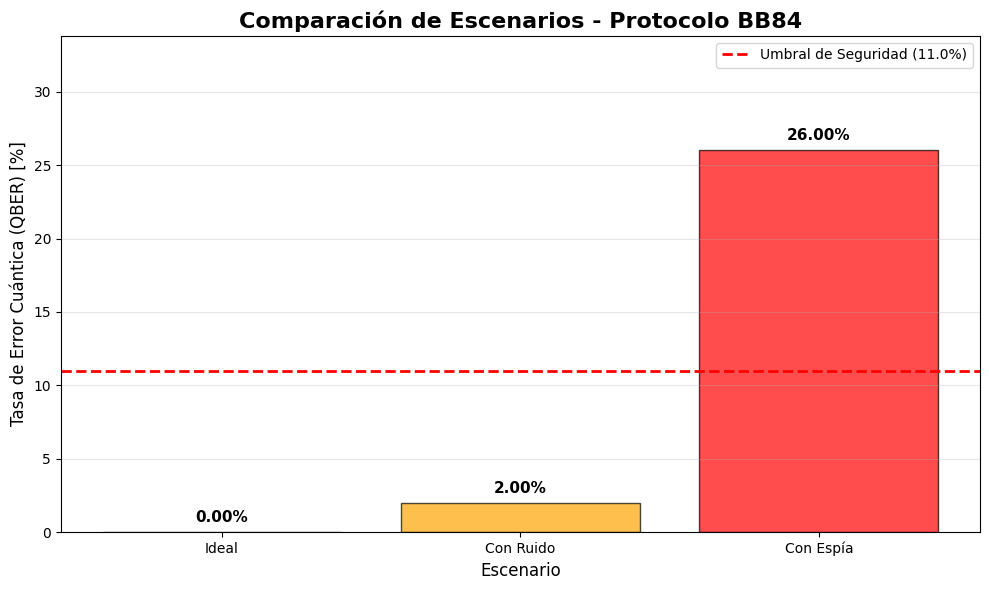

In [15]:
plot_scenarios_comparison(resultados_globales)


### 10.2 Probabilidad de Detección de Espía


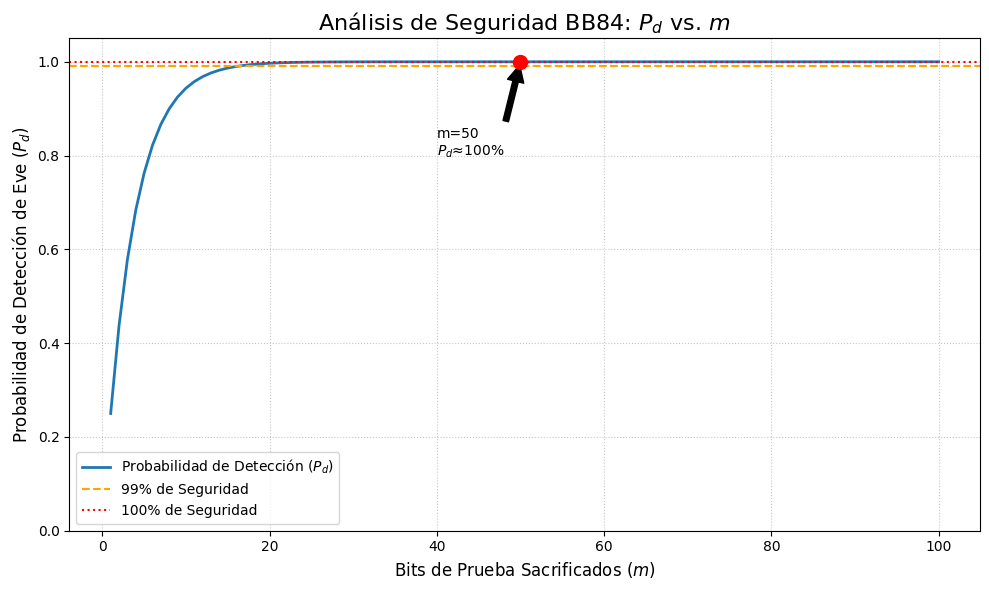

In [16]:
plot_detection_probability()


### 10.3 Análisis de Sensibilidad al Ruido

Análisis detallado del impacto de cada tipo de ruido cuántico en el QBER.



📊 Analizando impacto de cada tipo de ruido...
  Depolarizing: QBER = 8.00%
  Phase Damping: QBER = 2.00%
  Amplitude Damping: QBER = 2.00%
  Readout: QBER = 2.00%


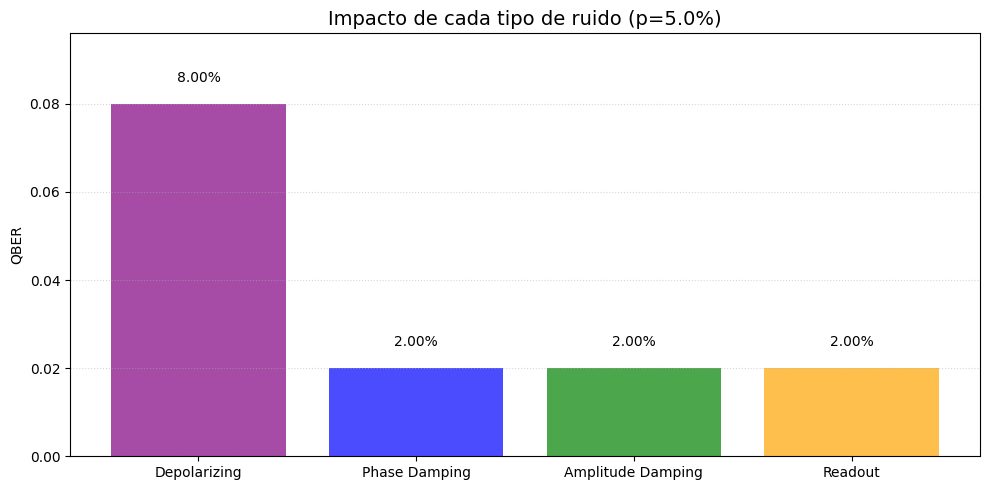

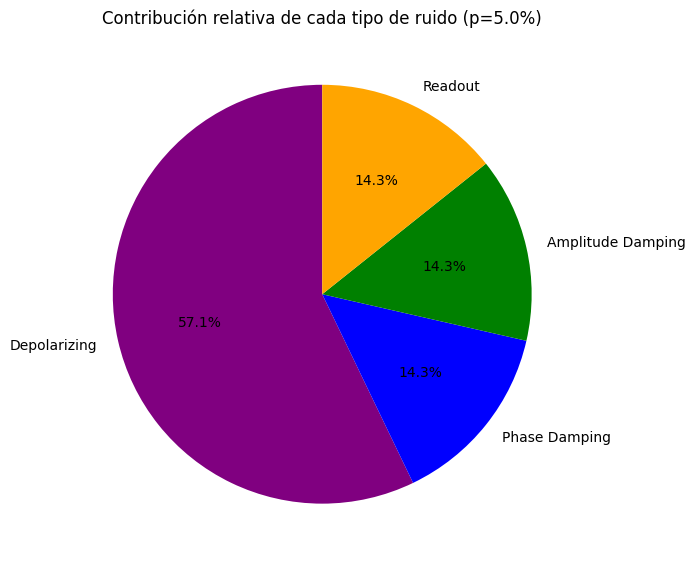

In [17]:
def medir_qber_con_ruido_individual(tipo_error, prob_error):
    """
    Ejecuta BB84 con un solo tipo de ruido activo.
    
    Args:
        tipo_error (str): Tipo de error ('Depolarizing', 'Phase Damping', etc.)
        prob_error (float): Probabilidad de error
        
    Returns:
        float: QBER medido
    """
    noise_model = NoiseModel()
    
    if tipo_error == 'Depolarizing':
        err = depolarizing_error(prob_error, 1)
        noise_model.add_all_qubit_quantum_error(err, ['u1','u2','u3','x','h'])
    elif tipo_error == 'Phase Damping':
        err = phase_damping_error(prob_error)
        noise_model.add_all_qubit_quantum_error(err, ['u1','u2','u3','x','h'])
    elif tipo_error == 'Amplitude Damping':
        err = amplitude_damping_error(prob_error)
        noise_model.add_all_qubit_quantum_error(err, ['u1','u2','u3','x','h'])
    elif tipo_error == 'Readout':
        err = ReadoutError([[1 - prob_error, prob_error],
                            [prob_error, 1 - prob_error]])
        noise_model.add_all_qubit_readout_error(err)
    else:
        raise ValueError("Tipo de error no reconocido")
    
    backend = AerSimulator(noise_model=noise_model)
    pm = generate_preset_pass_manager(backend=backend, optimization_level=0)
    sampler = Sampler(mode=backend)
    
    np.random.seed()
    bases_bob_temp = generar_bases_bob(N_QUBITS)
    bits_alice_temp = np.random.randint(2, size=N_QUBITS)
    bases_alice_temp = np.random.randint(2, size=N_QUBITS)
    circuitos_temp = [encode_qubit(bits_alice_temp[i], bases_alice_temp[i]) 
                      for i in range(N_QUBITS)]
    
    stdout_original = sys.stdout
    sys.stdout = io.StringIO()
    
    bits_bob_temp = medir_qubits_bob(circuitos_temp, bases_bob_temp, pm, sampler)
    sifted_a, sifted_b = sift_keys(bases_alice_temp, bases_bob_temp, 
                                    bits_alice_temp, bits_bob_temp)
    
    sys.stdout = stdout_original
    
    if len(sifted_a) < TEST_SIZE:
        return np.nan
    
    qber_temp, _ = check_for_eve(sifted_a, sifted_b, TEST_SIZE)
    return qber_temp


# Análisis de cada tipo de ruido
print("\n📊 Analizando impacto de cada tipo de ruido...")
errores = ['Depolarizing', 'Phase Damping', 'Amplitude Damping', 'Readout']
prob_fija = 0.05
qber_por_error = []

for tipo in errores:
    q = medir_qber_con_ruido_individual(tipo, prob_fija)
    qber_por_error.append(q)
    print(f"  {tipo}: QBER = {q:.2%}")

# Gráfico de barras
plt.figure(figsize=(10, 5))
plt.bar(errores, qber_por_error, color=['purple','blue','green','orange'], alpha=0.7)
plt.title(f'Impacto de cada tipo de ruido (p={prob_fija*100}%)', fontsize=14)
plt.ylabel('QBER')
plt.ylim(0, max([x for x in qber_por_error if not np.isnan(x)]) * 1.2)
for i, q in enumerate(qber_por_error):
    if not np.isnan(q):
        plt.text(i, q + 0.005, f"{q:.2%}", ha='center', fontsize=10)
plt.grid(axis='y', linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()

# Pie chart
qber_validos = [q for q in qber_por_error if not np.isnan(q)]
errores_validos = [e for e, q in zip(errores, qber_por_error) if not np.isnan(q)]

if len(qber_validos) > 0:
    plt.figure(figsize=(7, 7))
    plt.pie(qber_validos, labels=errores_validos, autopct='%1.1f%%',
            startangle=90, colors=['purple','blue','green','orange'][:len(qber_validos)])
    plt.title(f'Contribución relativa de cada tipo de ruido (p={prob_fija*100}%)', fontsize=12)
    plt.tight_layout()
    plt.show()
